In [1]:
# neutral_calm, happy, sad, angry


In [2]:
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report


In [3]:
df_train = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df_val   = pd.read_csv(r"D:\SER_Cross\data\processed\val.csv")
df_test  = pd.read_csv(r"D:\SER_Cross\data\processed\test.csv")

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print("Total samples:", len(df_all))


Total samples: 7227


In [4]:
emotion_map = {
    "neutral": "neutral_calm",
    "calm": "neutral_calm",
    "happy": "happy",
    "sad": "sad",
    "angry": "angry"
}

df_all["emotion_4"] = df_all["emotion"].map(emotion_map)
df_all = df_all.dropna(subset=["emotion_4"])

print(df_all["emotion_4"].value_counts())


emotion_4
happy           1463
sad             1463
angry           1463
neutral_calm    1375
Name: count, dtype: int64


In [5]:
SAMPLE_RATE = 22050
DURATION = 4
N_MELS = 128
MAX_LEN = 173

def spec_augment(mel):
    mel = mel.copy()
    t = mel.shape[1]
    t0 = np.random.randint(0, t - 20)
    mel[:, t0:t0+20] = 0
    return mel

def extract_logmel(path, augment=False):
    y, sr = librosa.load(path, sr=SAMPLE_RATE, duration=DURATION)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS,
        n_fft=1024, hop_length=512
    )

    logmel = librosa.power_to_db(mel)
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-6)

    if augment:
        logmel = spec_augment(logmel)

    if logmel.shape[1] < MAX_LEN:
        logmel = np.pad(logmel, ((0,0),(0,MAX_LEN-logmel.shape[1])))
    else:
        logmel = logmel[:, :MAX_LEN]

    return logmel.T   # (time, mel)


In [6]:
X = np.array([
    extract_logmel(p, augment=False)
    for p in df_all["path"]
])


In [7]:
#Encode 4-Class Labels
le = LabelEncoder()
y = le.fit_transform(df_all["emotion_4"])

print("Classes:", le.classes_)


Classes: ['angry' 'happy' 'neutral_calm' 'sad']


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (4034, 173, 128)
Val: (865, 173, 128)
Test: (865, 173, 128)


In [9]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: 0.98486328125, 1: 0.98486328125, 2: 1.0483367983367984, 3: 0.98486328125}


In [10]:
model = tf.keras.Sequential([
    layers.Conv1D(64, 5, activation="relu", input_shape=(173,128)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 5, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Bidirectional(layers.LSTM(128)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")   # 🔥 4 classes
])


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 169, 64)           41024     
                                                                 
 batch_normalization (Batch  (None, 169, 64)           256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 84, 64)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 80, 128)           41088     
                                                                 
 batch_normalization_1 (Bat  (None, 80, 128)           512       
 chNormalization)                                                
                                                        

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weights
)


Epoch 1/40
127/127 [==============================] - 12s 68ms/step - loss: 1.0560 - accuracy: 0.5317 - val_loss: 0.9070 - val_accuracy: 0.6197
Epoch 2/40
127/127 [==============================] - 7s 54ms/step - loss: 0.9186 - accuracy: 0.6123 - val_loss: 0.9168 - val_accuracy: 0.6012
Epoch 3/40
127/127 [==============================] - 7s 52ms/step - loss: 0.8407 - accuracy: 0.6537 - val_loss: 0.9854 - val_accuracy: 0.5838
Epoch 4/40
127/127 [==============================] - 7s 53ms/step - loss: 0.7857 - accuracy: 0.6847 - val_loss: 0.8285 - val_accuracy: 0.6751
Epoch 5/40
127/127 [==============================] - 7s 55ms/step - loss: 0.7612 - accuracy: 0.6904 - val_loss: 0.9471 - val_accuracy: 0.6116
Epoch 6/40
127/127 [==============================] - 7s 58ms/step - loss: 0.6941 - accuracy: 0.7189 - val_loss: 0.7921 - val_accuracy: 0.6936
Epoch 7/40
127/127 [==============================] - 7s 57ms/step - loss: 0.6569 - accuracy: 0.7365 - val_loss: 0.7353 - val_accuracy: 0.685

In [13]:
# Save trained CRNN 4-class model
model.save(r"D:\SER_Cross\models\crnn_4class_model.h5")
print("CRNN 4-class model saved successfully")


CRNN 4-class model saved successfully


c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
import os
print(os.listdir(r"D:\SER_Cross\models"))


['crnn_3emotion_final.h5', 'crnn_4class_model.h5', 'text_model_3emotion.pkl', 'text_vectorizer_3emotion.pkl']


In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Final 4-Class Test Accuracy:", test_acc)


28/28 [==============================] - 1s 21ms/step - loss: 1.4010 - accuracy: 0.6902
Final 4-Class Test Accuracy: 0.6901733875274658


In [16]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))


28/28 [==============================] - 1s 20ms/step
              precision    recall  f1-score   support

       angry       0.74      0.78      0.76       220
       happy       0.66      0.62      0.64       219
neutral_calm       0.63      0.67      0.65       207
         sad       0.73      0.69      0.71       219

    accuracy                           0.69       865
   macro avg       0.69      0.69      0.69       865
weighted avg       0.69      0.69      0.69       865



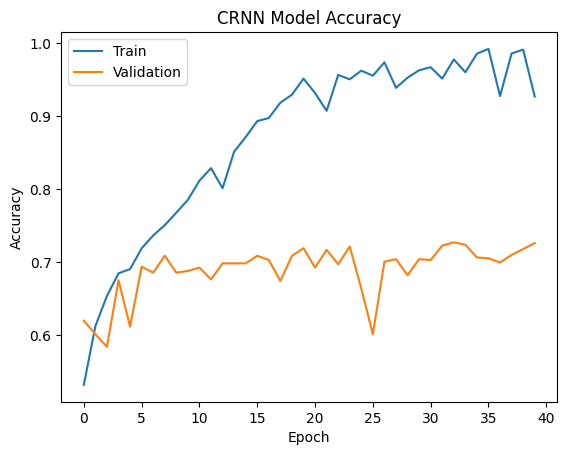

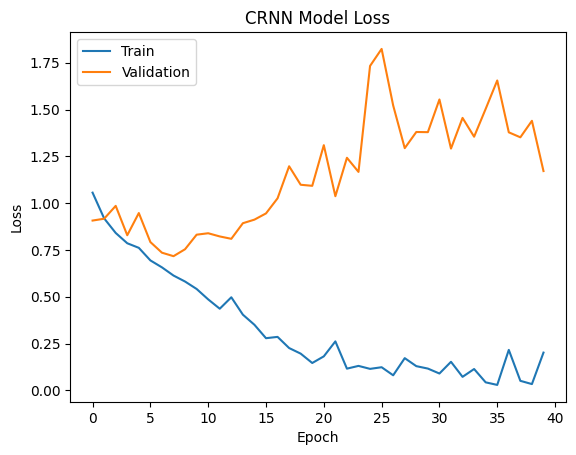

In [17]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CRNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CRNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [18]:
import sys
print(sys.executable)

c:\Users\Asus\anaconda3\envs\ser_env\python.exe
